# SDM on the ResNet-18: a first experiment

**Goal:** apply the **Similarity-Distance-Magnitude (SDM)** estimator to the ResNet-18 trained in [notebook 02](02_cifar100_cnn_resnet18.ipynb), and compare it with the temperature-scaling baseline on the same images.

SDM decides whether to trust a prediction by looking at the model's **embedding** of the image:

- **Similarity**: do the nearest training images (in embedding space) share the predicted label?
- **Distance**: how far is the image from the training images it resembles?
- **Magnitude**: how strongly does the output layer favor the predicted class?

It then calibrates these signals on the calibration split and assigns each image an **α**: an estimate that the image falls in a region where accuracy *for its class and predicted class* is at least α. An image with α = 0 belongs to no region and should be treated as out-of-distribution. We use the [`reexpress-sdm`](https://pypi.org/project/reexpress-sdm/) package, version 0.4.9.

This notebook:

1. rebuilds the trained ResNet-18 from `outputs/cifar100_resnet18.pt` and computes embeddings for the training, calibration, and validation splits,
2. **Experiment A**: SDM on all **100 classes**,
3. **Experiment B**: SDM on the **20 broader groups**, a pilot with five times more calibration images per label,
4. shows the nearest training images SDM uses to justify its decisions.

**Before running:** run notebook 02 first, so the checkpoint exists. Install the extra package with `python -m pip install -r requirements.txt`. The whole notebook takes about 12 minutes on an Apple M3 Pro: two SDM fits of about 5 minutes each.

## 1. Settings and tools

In [1]:
%pip install "numpy==1.26.4"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import hashlib
import pickle
import tarfile
import time

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reexpress_sdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from reexpress_sdm import SDMModel, TorchTrainer, TrainingConfig, write_artifact

SDM_EPOCHS = 20        # the package default
SDM_SEED = 0
TARGET_ALPHA = 0.95    # the reliability level we want, as in notebook 02
SAVE_SDM_MODELS = False  # each saved SDM model takes about 190 MB; retraining takes about 5 minutes
OUTPUT_DIR = Path("../outputs")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"PyTorch {torch.__version__}, reexpress-sdm {reexpress_sdm.__version__}, device: {device}")

PyTorch 2.5.1, reexpress-sdm 0.4.9, device: mps


## 2. Load the data and the trained ResNet-18

The data loader is the same as in the earlier notebooks. The network class must match notebook 02 exactly so the saved weights fit. The checkpoint also stores the split indices, so we use exactly the same training, calibration, and validation images.

In [3]:
DATA_DIR = Path("../data")  # the repository's data/ folder
data_path = DATA_DIR / "cifar-100-python"

if not data_path.exists():
    archive_path = DATA_DIR / "cifar-100-python.tar.gz"
    if archive_path.exists():
        with tarfile.open(archive_path) as archive:
            archive.extractall(DATA_DIR, filter="data")
    else:
        data_path = Path(kagglehub.dataset_download("aakash119/cifar-100-python-tar-gz")) / "cifar-100-python"

expected_md5 = {
    "train": "16019d7e3df5f24257cddd939b257f8d",
    "meta": "7973b15100ade9c7d40fb424638fde48",
}
for name, md5 in expected_md5.items():
    assert hashlib.md5((data_path / name).read_bytes()).hexdigest() == md5, f"{name} is not the official file; delete {data_path} and rerun"

with (data_path / "train").open("rb") as file:
    training = pickle.load(file, encoding="latin1")
with (data_path / "meta").open("rb") as file:
    metadata = pickle.load(file, encoding="latin1")
all_images = training["data"].reshape(-1, 3, 32, 32)
all_labels = np.array(training["fine_labels"])
all_groups = np.array(training["coarse_labels"])
class_names = metadata["fine_label_names"]
group_names = metadata["coarse_label_names"]

In [4]:
# Same architecture as notebook 02.
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class CifarResNet(nn.Module):
    def __init__(self, num_classes=100, widths=(64, 128, 256, 512)):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, widths[0], 3, padding=1, bias=False), nn.BatchNorm2d(widths[0]), nn.ReLU())
        stages, in_channels = [], widths[0]
        for i, width in enumerate(widths):
            stride = 1 if i == 0 else 2
            stages.append(nn.Sequential(ResidualBlock(in_channels, width, stride), ResidualBlock(width, width)))
            in_channels = width
        self.stages = nn.Sequential(*stages)
        self.classifier = nn.Linear(widths[-1], num_classes)

    def embed(self, x):
        return F.adaptive_avg_pool2d(self.stages(self.stem(x)), 1).flatten(1)

    def forward(self, x):
        return self.classifier(self.embed(x))


checkpoint = torch.load(OUTPUT_DIR / "cifar100_resnet18.pt", map_location=device, weights_only=False)
model = CifarResNet(num_classes=len(class_names)).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()
channel_mean = checkpoint["channel_mean"].to(device)
channel_std = checkpoint["channel_std"].to(device)
splits = checkpoint["split_indices"]          # train / validation / calibration indices into the training file
TEMPERATURE = checkpoint["temperature"]       # fitted in notebook 02 on the calibration split
print({name: len(index) for name, index in splits.items()}, f"temperature {TEMPERATURE:.2f}")

{'train': 45000, 'validation': 2500, 'calibration': 2500} temperature 1.29


## 3. Compute embeddings

SDM works on the **512-number embedding** each image gets just before the ResNet's final layer. We compute it, plus the logits, for every image in each split. No augmentation is applied.

The **training** embeddings become SDM's *support set*: the reference images it searches for nearest neighbors. The **calibration** embeddings fit SDM's regions. The **validation** embeddings are only used to check the result.

In [5]:
@torch.no_grad()
def embed_images(images, batch_size=500):
    embeddings, logits = [], []
    for start in range(0, len(images), batch_size):
        batch = torch.from_numpy(images[start : start + batch_size]).to(device)
        features = model.embed((batch.float() / 255 - channel_mean) / channel_std)
        embeddings.append(features.cpu())
        logits.append(model.classifier(features).cpu())
    return torch.cat(embeddings).numpy(), torch.cat(logits)

data = {}
for name, index in splits.items():
    embeddings, logits = embed_images(all_images[index])
    data[name] = {"index": index, "embeddings": embeddings, "logits": logits,
                  "labels": all_labels[index], "groups": all_groups[index]}

pd.DataFrame({
    name: {"images": len(split["labels"]),
           "ResNet accuracy": f"{(split['logits'].argmax(1).numpy() == split['labels']).mean():.1%}"}
    for name, split in data.items()
}).T

,images,ResNet accuracy
train,45000,99.1%
validation,2500,74.2%
calibration,2500,75.6%


The ResNet is right on about 99% of its **training** images, because it has nearly memorized them, but only about 74% on validation. Keep this in mind: SDM compares new images with these training embeddings, which are much more tightly clustered than embeddings of new images.

We save all embeddings so later experiments can skip this step.

In [6]:
np.savez_compressed(
    OUTPUT_DIR / "cifar100_resnet18_embeddings.npz",
    **{f"{name}_{key}": (value.numpy() if torch.is_tensor(value) else value)
       for name, split in data.items() for key, value in split.items()},
)
print("Saved", OUTPUT_DIR / "cifar100_resnet18_embeddings.npz")

Saved ../outputs/cifar100_resnet18_embeddings.npz


## 4. Tools shared by both experiments

- `fit_sdm` trains SDM on the training embeddings and calibrates it on the calibration embeddings. Calling the trainer directly keeps **our** splits; the command-line tool would otherwise pool and reshuffle them. Set `SAVE_SDM_MODELS = True` to keep the fitted models in `outputs/` (about 190 MB each, mostly a copy of the 45,000 support embeddings).
- `region_blockers` explains a model with no regions (see Experiment A).
- `selective_summary` reports coverage and selective accuracy with a 95% Wilson interval, as in notebook 02, plus the **worst per-label accuracy** among admitted images, because SDM's promise is per label, not just on average.

In [7]:
def fit_sdm(number_of_classes, train_labels, calibration_labels, label_names, name):
    start = time.time()
    trainer = TorchTrainer(TrainingConfig(number_of_classes=number_of_classes, epochs=SDM_EPOCHS, seed=SDM_SEED), device=str(device))
    result = trainer.fit(
        data["train"]["embeddings"], train_labels.tolist(),
        data["calibration"]["embeddings"], calibration_labels.tolist(),
        train_ids=[f"train-{i}" for i in data["train"]["index"]],
        calibration_ids=[f"train-{i}" for i in data["calibration"]["index"]],
        class_names=label_names,
        representation_fingerprint="cifar100_resnet18_avgpool512_v1",
    )
    if SAVE_SDM_MODELS:
        write_artifact(OUTPUT_DIR / f"{name}.sdmkitmodel", result.artifact, overwrite=True)
    regions = [round(region["alpha"], 2) for region in result.artifact.manifest["regions"]]
    print(f"{name}: best epoch {result.best_epoch}, {time.time() - start:.0f}s, regions at alpha = {regions or 'none'}")
    return result.artifact


def region_blockers(artifact, number_of_classes):
    # For each alpha, find the similarity cutoff that leaves the fewest failing labels.
    rows = artifact.calibration_rows
    probs = np.array([row["sdm"] for row in rows], dtype=np.float32)
    q_prime = np.array([row["qPrime"] for row in rows], dtype=np.float32)
    labels = np.array([int(row["label"]) for row in rows])
    p_true = probs[np.arange(len(labels)), labels]
    passes = np.floor(q_prime) > artifact.manifest["configuration"]["oodLimit"]
    table = {}
    for alpha in np.arange(0.95, 0.5, -0.05):
        best = None
        for cutoff in np.unique(q_prime[passes]):
            kept = passes & (q_prime >= cutoff)
            count = np.bincount(labels[kept], minlength=number_of_classes)
            misses = np.bincount(labels[kept & (p_true < alpha)], minlength=number_of_classes)
            empty = int((count == 0).sum())
            too_many = int(((count > 0) & (misses > np.floor((1 - alpha) * count))).sum())
            if best is None or empty + too_many < best[0] + best[1]:
                best = (empty, too_many)
        table[f"{alpha:.2f}"] = {"labels with no images left": best[0], "labels with too many misses": best[1]}
    return pd.DataFrame(table).T.rename_axis("alpha")


def wilson_interval(successes, n, z=1.96):
    p = successes / n
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denominator
    half_width = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return center - half_width, center + half_width


def selective_summary(admitted, predictions, labels):
    n = int(admitted.sum())
    correct = predictions[admitted] == labels[admitted]
    if n == 0:
        return {"coverage": "0.0%", "images answered": 0, "selective accuracy": "-", "95% interval": "-", "worst label accuracy": "-"}
    low, high = wilson_interval(correct.sum(), n)
    per_label = pd.Series(correct).groupby(labels[admitted]).mean()
    return {
        "coverage": f"{admitted.mean():.1%}",
        "images answered": n,
        "selective accuracy": f"{correct.mean():.1%}",
        "95% interval": f"{low:.1%} – {high:.1%}",
        "worst label accuracy": f"{per_label.min():.0%} ({len(per_label)} labels)",
    }


def choose_threshold(confidence, correct, target, conservative=False):
    order = np.argsort(-confidence)
    answered = np.arange(1, len(order) + 1)
    hits = np.cumsum(correct[order])
    score = wilson_interval(hits, answered)[0] if conservative else hits / answered
    meets = np.flatnonzero(score >= target)
    return None if len(meets) == 0 else float(confidence[order][meets.max()])


def score_validation(artifact, nearest_exemplars=0):
    sdm = SDMModel(artifact, device=str(device))
    scores = sdm.score(data["validation"]["embeddings"], ids=[f"train-{i}" for i in data["validation"]["index"]],
                       nearest_exemplars=nearest_exemplars)
    return {
        "scores": scores,
        "prediction": np.array([score.prediction for score in scores]),
        "centroid_alpha": np.array([score.centroid_region_alpha for score in scores]),
        "lower_alpha": np.array([score.lower_region_alpha for score in scores]),
        "is_ood": np.array([score.is_ood for score in scores]),
    }

## 5. Experiment A: SDM on all 100 classes

SDM's calibration creates a region at level α only if there is **one similarity cutoff at which every class at once**:

1. still has at least one calibration image above the cutoff, and
2. has nearly all of those images given at least α probability for their true class. At α = 0.95 that allows 1 miss in 25 images, and **no misses** once fewer than 20 images remain.

With only **25 calibration images per class**, that is a demanding test across 100 classes.

In [8]:
sdm_fine = fit_sdm(100, data["train"]["labels"], data["calibration"]["labels"], class_names, "sdm_resnet18_fine100")
fine = score_validation(sdm_fine)
y_fine = data["validation"]["labels"]

print(f"SDM's own prediction accuracy on validation: {(fine['prediction'] == y_fine).mean():.1%} "
      f"(the ResNet itself: {(data['validation']['logits'].argmax(1).numpy() == y_fine).mean():.1%})")
print(f"validation images flagged out-of-distribution by SDM: {fine['is_ood'].mean():.1%}")
print(f"validation images in any region (alpha > 0): {(fine['centroid_alpha'] > 0).mean():.1%}")

sdm_resnet18_fine100: best epoch 19, 593s, regions at alpha = none
SDM's own prediction accuracy on validation: 70.8% (the ResNet itself: 74.2%)
validation images flagged out-of-distribution by SDM: 23.1%
validation images in any region (alpha > 0): 0.0%


If no region was formed, every image gets α = 0 and SDM admits nothing. The table below shows why: for each α, the best possible cutoff and how many classes still fail.

In [9]:
region_blockers(sdm_fine, 100)

,labels with no images left,labels with too many misses
alpha,,
0.95,24,9
0.90,22,8
0.85,10,11
0.80,10,4
0.75,7,5
0.70,7,5
0.65,7,3
0.60,5,4
0.55,5,1


**Reading the table:** a region needs **0 failing classes** in a row. "No images left" means a cutoff strict enough to drop the misses also removes *every* calibration image of some classes; with only 25 images each, that happens quickly. "Too many misses" means even the best cutoff leaves a class with more low-probability images than α allows.

Two causes stand out:

- **Too few calibration images per class.** The per-class rule needs more than 25 images to tolerate any misses at all.
- **Memorized training embeddings.** SDM's first gate requires the nearest training images to agree with the prediction. Because training images are tightly clustered by class, many new images land next to a different class and fail that gate.

Experiment B tests the first cause directly.

## 6. Experiment B: SDM on the 20 broader groups

We keep the same embeddings and the same images, but use the **20 broader groups** (for example *trees*, *vehicles 1*) as labels. Each group has **125 calibration images** instead of 25. If SDM forms regions here, the 100-class failure is mainly about calibration size.

For a fair comparison, the softmax baseline is converted to groups too: a group's probability is the sum of the temperature-scaled probabilities of its five classes. Its thresholds are chosen on the calibration split exactly as in notebook 02.

In [10]:
sdm_coarse = fit_sdm(20, data["train"]["groups"], data["calibration"]["groups"], group_names, "sdm_resnet18_coarse20")
coarse = score_validation(sdm_coarse, nearest_exemplars=5)
y_coarse = data["validation"]["groups"]
print(f"SDM's own prediction accuracy on the 20 groups: {(coarse['prediction'] == y_coarse).mean():.1%}")

sdm_resnet18_coarse20: best epoch 20, 593s, regions at alpha = [0.95, 0.9, 0.7, 0.55]
SDM's own prediction accuracy on the 20 groups: 79.7%


In [11]:
# Temperature-scaled softmax, summed into the 20 groups.
fine_to_group = np.zeros(100, dtype=int)
fine_to_group[all_labels] = all_groups

def group_probabilities(logits):
    probs = (logits / TEMPERATURE).softmax(1).numpy()
    grouped = np.zeros((len(probs), 20))
    np.add.at(grouped.T, fine_to_group, probs.T)
    return grouped

cal_group_probs = group_probabilities(data["calibration"]["logits"])
val_group_probs = group_probabilities(data["validation"]["logits"])
cal_correct = cal_group_probs.argmax(1) == data["calibration"]["groups"]
val_confidence, val_prediction = val_group_probs.max(1), val_group_probs.argmax(1)

rows = {}
for rule, conservative in [("softmax + temperature, plain", False), ("softmax + temperature, conservative", True)]:
    threshold = choose_threshold(cal_group_probs.max(1), cal_correct, TARGET_ALPHA, conservative)
    admitted = val_confidence >= threshold if threshold is not None else np.zeros(len(y_coarse), bool)
    rows[rule] = selective_summary(admitted, val_prediction, y_coarse)
for alpha in [0.90, 0.95]:
    rows[f"SDM, centroid alpha ≥ {alpha:.2f}"] = selective_summary(coarse["centroid_alpha"] >= alpha, coarse["prediction"], y_coarse)
    rows[f"SDM, lower alpha ≥ {alpha:.2f}"] = selective_summary(coarse["lower_alpha"] >= alpha, coarse["prediction"], y_coarse)

pd.DataFrame(rows).T.rename_axis("validation, 20 groups")

,coverage,images answered,selective accuracy,95% interval,worst label accuracy
"validation, 20 groups",,,,,
"softmax + temperature, plain",76.8%,1921,93.9%,92.7% – 94.8%,86% (20 labels)
"softmax + temperature, conservative",71.5%,1787,95.5%,94.4% – 96.3%,88% (20 labels)
"SDM, centroid alpha ≥ 0.90",44.1%,1102,98.2%,97.2% – 98.8%,90% (20 labels)
"SDM, lower alpha ≥ 0.90",34.6%,864,98.8%,97.9% – 99.4%,88% (20 labels)
"SDM, centroid alpha ≥ 0.95",16.1%,403,99.5%,98.2% – 99.9%,83% (20 labels)
"SDM, lower alpha ≥ 0.95",14.4%,360,100.0%,98.9% – 100.0%,100% (20 labels)


**How to read this table:**

- **Coverage** is the share of validation images the method answers; **selective accuracy** is the accuracy on those. A better method answers more images at the same accuracy.
- **Worst label accuracy** is the lowest accuracy among the groups among admitted images. SDM aims to keep *every* group at α or above, not just the average.
- The softmax thresholds aim at exactly 95% overall. SDM's regions are deliberately stricter: per label, with a margin. So compare SDM at α ≥ 0.95 with the **conservative** softmax row, and look at both coverage and the worst-label column.

### Which groups does SDM admit?

Coverage per group, for SDM at α ≥ 0.95 and for the conservative softmax rule. Groups the model finds hard should be admitted less.

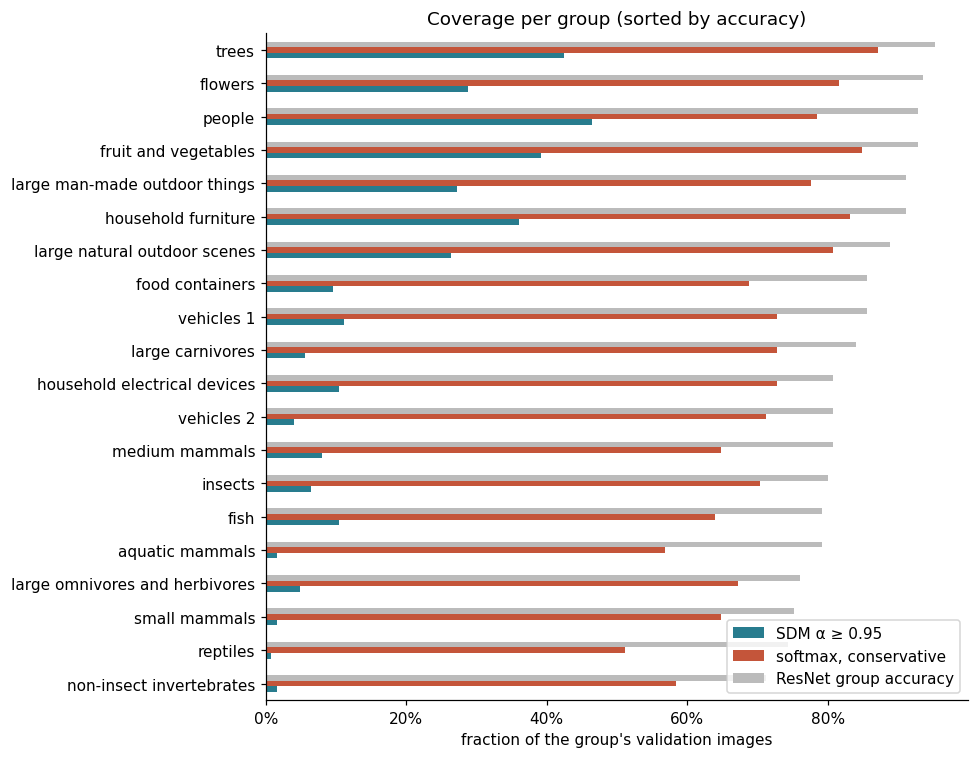

In [12]:
conservative_threshold = choose_threshold(cal_group_probs.max(1), cal_correct, TARGET_ALPHA, conservative=True)
per_group = pd.DataFrame({
    "SDM α ≥ 0.95": pd.Series(coarse["centroid_alpha"] >= TARGET_ALPHA).groupby(y_coarse).mean(),
    "softmax, conservative": pd.Series(val_confidence >= (conservative_threshold or np.inf)).groupby(y_coarse).mean(),
    "ResNet group accuracy": pd.Series(val_prediction == y_coarse).groupby(y_coarse).mean(),
})
per_group.index = [group_names[i].replace("_", " ") for i in per_group.index]
ax = per_group.sort_values("ResNet group accuracy").plot.barh(figsize=(9, 7), color=["#287c8e", "#c4553a", "#bbbbbb"])
ax.set(xlabel="fraction of the group's validation images", title="Coverage per group (sorted by accuracy)")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout()
plt.show()

## 7. Interpretability by example: the nearest training images

For every decision, SDM can show the **training images closest to the query** in its embedding space. Each row below shows one validation image (left) and its five nearest training images, with their true group. The top rows were admitted at α ≥ 0.95. The bottom rows were rejected (α = 0), so their neighbors often disagree.

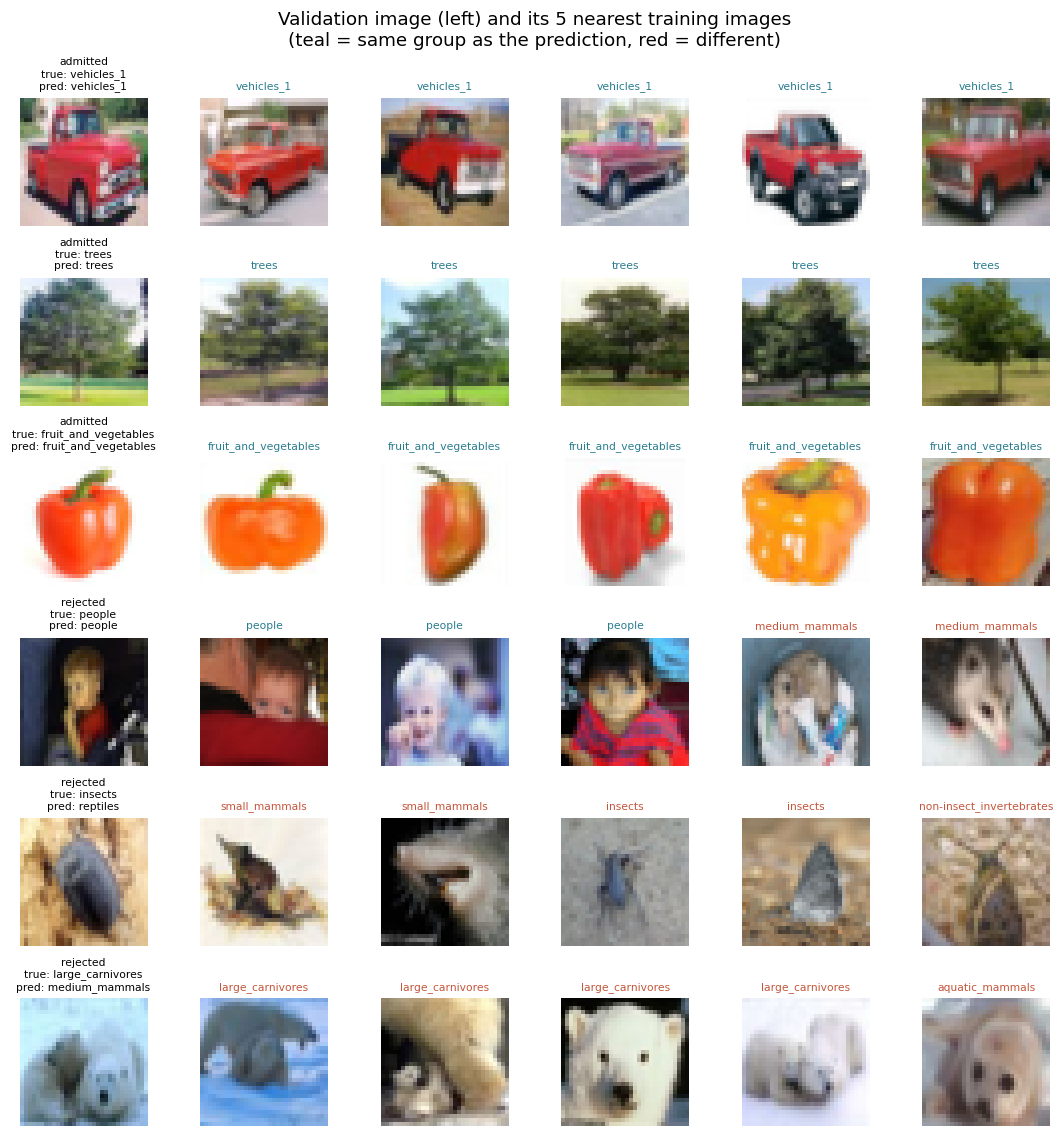

In [13]:
rng = np.random.default_rng(0)
admitted_ids = rng.choice(np.flatnonzero(coarse["centroid_alpha"] >= TARGET_ALPHA), size=3, replace=False)
rejected_ids = rng.choice(np.flatnonzero(coarse["centroid_alpha"] == 0), size=3, replace=False)
train_index = data["train"]["index"]

fig, axes = plt.subplots(6, 6, figsize=(10, 10.5))
for row, (i, status) in enumerate([(i, "admitted") for i in admitted_ids] + [(i, "rejected") for i in rejected_ids]):
    query = data["validation"]["index"][i]
    axes[row, 0].imshow(all_images[query].transpose(1, 2, 0), interpolation="nearest")
    axes[row, 0].set_title(f"{status}\ntrue: {group_names[y_coarse[i]]}\npred: {group_names[coarse['prediction'][i]]}", fontsize=7)
    for ax, match in zip(axes[row, 1:], coarse["scores"][i].nearest_support_matches):
        neighbor = train_index[match.support_index]
        ax.imshow(all_images[neighbor].transpose(1, 2, 0), interpolation="nearest")
        ax.set_title(group_names[match.label], fontsize=7, color="#287c8e" if match.label == coarse["prediction"][i] else "#c4553a")
    for ax in axes[row]:
        ax.axis("off")
fig.suptitle("Validation image (left) and its 5 nearest training images\n(teal = same group as the prediction, red = different)", fontsize=12)
plt.tight_layout()
plt.show()

## 8. What we learned and what to try next

Write your observations here. Questions to answer:

1. **Experiment A:** did SDM form any region on 100 classes? Which cause dominates in the blocker table: classes running out of images, or too many misses?
2. **Experiment B:** at α ≥ 0.95, how does SDM's coverage compare with the conservative softmax rule? Is its worst-group accuracy higher?
3. Do the nearest training images make the rejected cases understandable?

Next experiments this suggests:

- **More calibration images per class** for 100 classes: for example retrain the ResNet on 37,500 images and calibrate on 10,000 (100 per class). That is the most direct fix for Experiment A.
- **A less memorized embedding**: stop ResNet training earlier, or add regularization, so training embeddings look more like those of new images.
- **Distribution shift**: score CIFAR-100-C and SVHN embeddings with the 20-group SDM model and compare admission rates with the softmax rule.